# 한강시민공원 이용 만족도

In [ ]:
import pandas as pd
df = pd.read_excel('data/한강시민공원+이용+만족도(2005_2010)_20221020110113.xlsx')
df = df.fillna(method='ffill')
df = df[df['구분별(1)']=='지역소분류'][['구분별(2)','만족도별(2)','2010']].rename(columns={'구분별(2)':'시군구','만족도별(2)':'만족도','2010':'비율'})
df = df[df['만족도']!='소계']

C:\Users\user\anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [26]:
df

,시군구,만족도,비율
175,종로구,매우 불만족,0.6
176,종로구,약간 불만족,3.8
177,종로구,보통,18.0
178,종로구,약간 만족,57.2
179,종로구,매우 만족,20.3
...,...,...,...
319,강동구,매우 불만족,0.4
320,강동구,약간 불만족,1.7
321,강동구,보통,11.3
322,강동구,약간 만족,71.8


In [32]:
group = df['시군구'].unique().tolist()

In [44]:
# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

Gulim


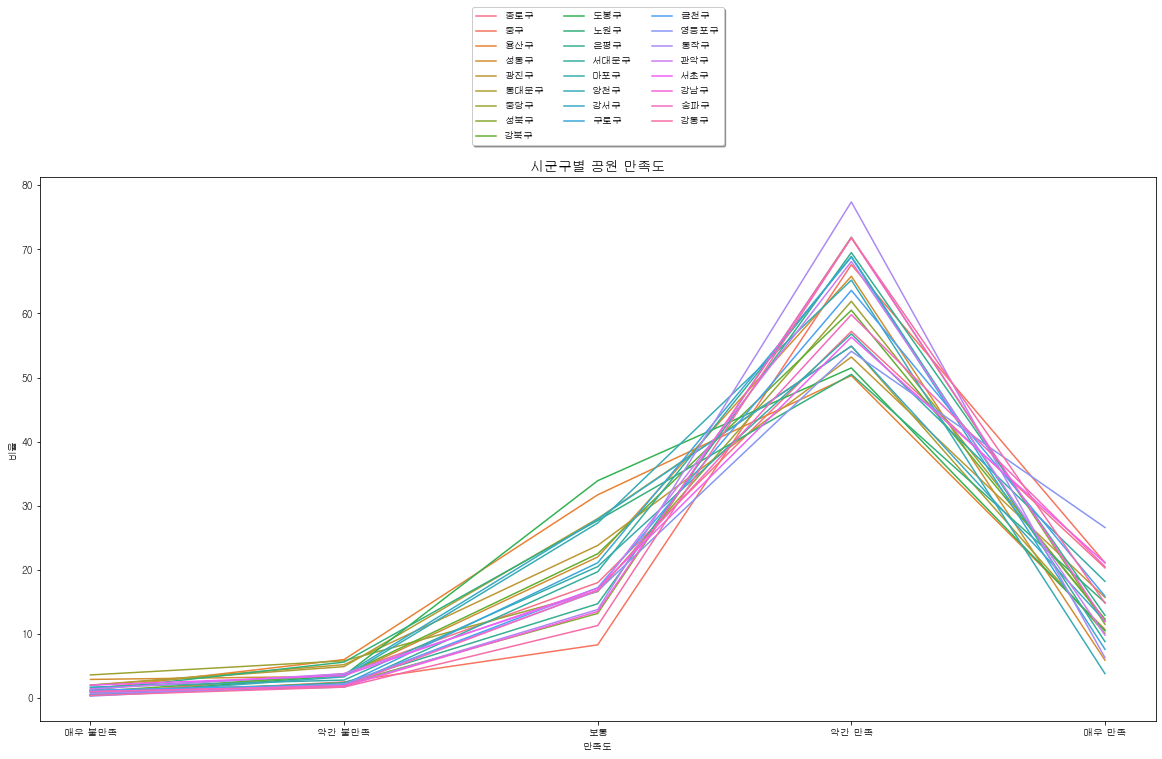

In [61]:
import seaborn as sns
plt.figure(figsize=(20,10))
ax = sns.lineplot(data=df, x='만족도', y='비율', hue='시군구')
plt.title('시군구별 공원 만족도',fontsize=14)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)


# 도시공원 이용 여부 빈도 및 만족도

In [71]:
import pandas as pd
df = pd.read_excel('data/도시공원_이용_여부__빈도__만족도_및_불편한_점_20221020110048.xlsx',header=2)
df.fillna(method='ffill',inplace=True)

C:\Users\user\anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [75]:
이용빈도 = df.iloc[:,:9]

# 지역별 녹지공원 만족도

In [15]:
import pandas as pd
df = pd.read_excel('data/지역+녹지+만족도_20221021174754.xlsx')
df = df.fillna(method='ffill')
df = df[df['구분별(1)']=='지역소분류']
df = df[df['항목']!='계']
df

C:\Users\user\anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,구분별(1),구분별(2),항목,2018,2019,2020,2021
207,지역소분류,종로구,매우 불만족 (점),1.6,0.7,1.1,2.9
208,지역소분류,종로구,약간 불만족 (점),15.4,3.8,8.1,10.1
209,지역소분류,종로구,보통 (점),54.7,54.4,56.6,44.8
210,지역소분류,종로구,약간 만족 (점),25.0,37.9,26.6,33.1
211,지역소분류,종로구,매우 만족 (점),3.3,3.2,7.6,9.2
...,...,...,...,...,...,...,...
376,지역소분류,강동구,약간 불만족 (점),14.8,10.1,15.2,12.7
377,지역소분류,강동구,보통 (점),40.0,49.6,42.5,44.2
378,지역소분류,강동구,약간 만족 (점),36.4,33.7,29.7,30.8
379,지역소분류,강동구,매우 만족 (점),2.2,6.2,11.5,10.4


In [ ]:
a = df[(df.항목 == '10점 평균 (%)')].groupby('구분별(2)').sum().reset_index()[['구분별(2)','2020']]

In [51]:
a.sort_values('2020')

,구분별(2),2020
7,금천구,5.54
10,동대문구,5.69
19,영등포구,5.69
4,관악구,5.77
22,종로구,5.79
2,강북구,5.80
21,은평구,5.82
9,도봉구,5.82
12,마포구,5.86
3,강서구,5.87


In [52]:
a.sort_values('2020')['2020'].to_list()

[5.54,
 5.69,
 5.69,
 5.77,
 5.79,
 5.8,
 5.82,
 5.82,
 5.86,
 5.87,
 5.88,
 5.88,
 5.89,
 5.91,
 5.92,
 5.94,
 5.98,
 5.99,
 6.02,
 6.04,
 6.08,
 6.13,
 6.15,
 6.2,
 6.34]

In [63]:
day = a.sort_values('2020')['구분별(2)'].to_list()
num_icecream = a.sort_values('2020')['2020'].to_list()

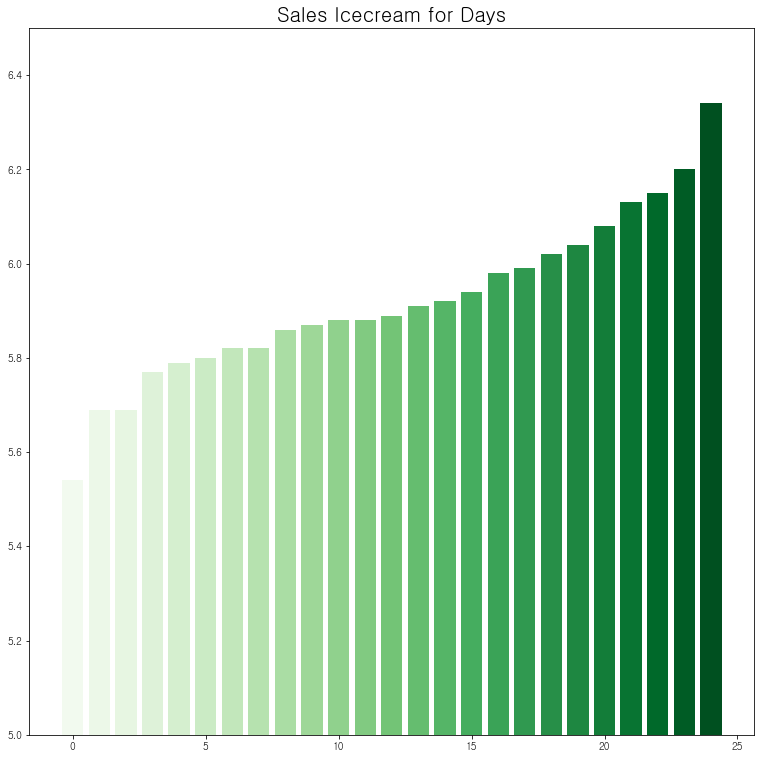

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(13,13)) ## Figure 생성 
fig.set_facecolor('white') ## Figure 배경색 지정
 
colors = sns.color_palette('Greens', len(day)) ## 바 차트 색상
 
xtick_label_position = list(range(len(day))) ## x축 눈금 라벨이 표시될 x좌표
 
plt.bar(xtick_label_position, num_icecream, color=colors) ## 바차트 출력
plt.title('Sales Icecream for Days', fontsize=20)
plt.ylim([5, 6.5])
plt.show()

In [72]:
fig.savefig("녹지공원만족도.png")

In [11]:
df_만족도.to_csv('data/정제데이터/구별_지역녹지만족도.csv',encoding='cp949',index=False)

Gulim


ValueError: Unable to parse string "-" at position 5

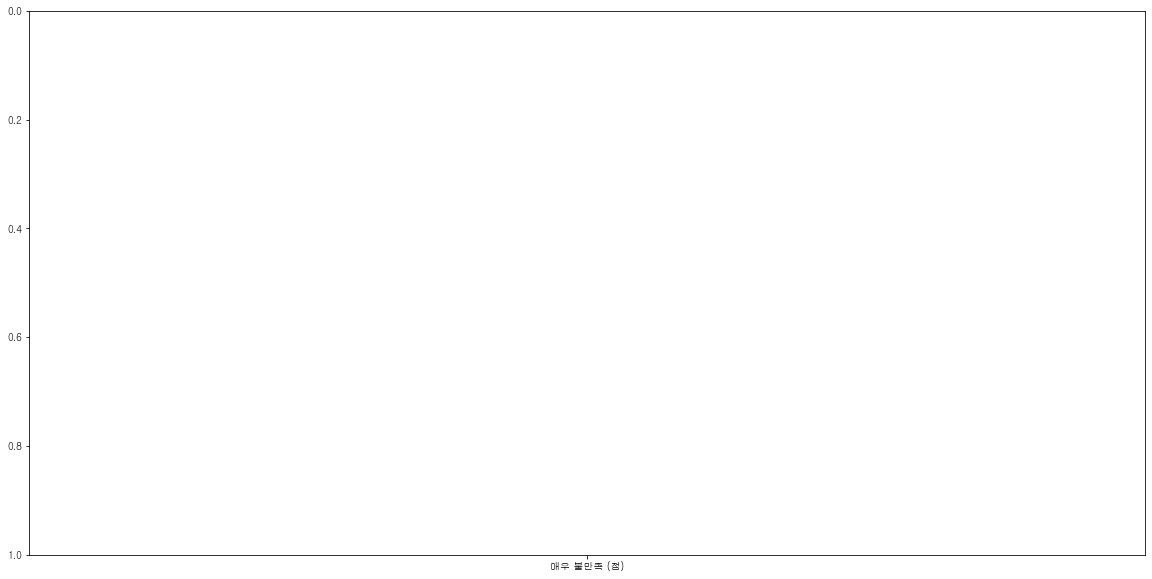

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize=(20,10))
ax = sns.lineplot(data=df, x='항목', y='2018', hue='구분별(2)')
plt.title('시군구별 공원 만족도',fontsize=14)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)

In [38]:
녹지만족도_2021.head(3)

,시군구,매우 불만족 (점),약간 불만족 (점),보통 (점),약간 만족 (점),매우 만족 (점)
30,종로구,1.6,15.4,54.7,25.0,3.3
31,중구,0.7,10.8,46.2,39.6,2.7
32,용산구,2.4,7.0,38.8,46.1,5.7


In [ ]:
df_1.transpose()

In [25]:
녹지만족도_2021=df[df['구분별(1)']=='지역소분류'][['구분별(2)','매우 불만족 (점)','약간 불만족 (점)','보통 (점)','약간 만족 (점)','매우 만족 (점)']].rename(columns={'구분별(2)':'시군구'})

In [37]:
import numpy as np
np.transpose(녹지만족도_2021.iloc[:,1:])

,30,31,32,33,34,35,36,37,38,39,...,45,46,47,48,49,50,51,52,53,54
매우 불만족 (점),1.6,0.7,2.4,2.2,0.8,2.7,0.9,0.2,3.5,1.9,...,1.7,2.5,2.3,4.2,2.7,2.5,0.5,0.7,0.3,6.7
약간 불만족 (점),15.4,10.8,7.0,8.8,8.5,16.7,13.9,12.1,14.4,10.6,...,17.8,13.9,29.9,11.9,14.8,9.4,9.5,11.3,10.8,14.8
보통 (점),54.7,46.2,38.8,38.6,33.7,43.0,42.9,46.2,48.3,37.2,...,52.2,38.5,29.8,23.6,57.7,29.7,37.0,42.8,31.1,40.0
약간 만족 (점),25.0,39.6,46.1,47.7,52.1,35.9,40.5,39.9,27.9,44.2,...,20.8,32.6,31.3,56.6,19.8,50.8,50.5,39.5,50.5,36.4
매우 만족 (점),3.3,2.7,5.7,2.6,4.9,1.8,1.8,1.6,5.8,6.2,...,7.4,12.5,6.7,3.8,5.0,7.5,2.5,5.7,7.3,2.2


In [26]:
녹지만족도_2021

,시군구,매우 불만족 (점),약간 불만족 (점),보통 (점),약간 만족 (점),매우 만족 (점)
30,종로구,1.6,15.4,54.7,25.0,3.3
31,중구,0.7,10.8,46.2,39.6,2.7
32,용산구,2.4,7.0,38.8,46.1,5.7
33,성동구,2.2,8.8,38.6,47.7,2.6
34,광진구,0.8,8.5,33.7,52.1,4.9
35,동대문구,2.7,16.7,43.0,35.9,1.8
36,중랑구,0.9,13.9,42.9,40.5,1.8
37,성북구,0.2,12.1,46.2,39.9,1.6
38,강북구,3.5,14.4,48.3,27.9,5.8
39,도봉구,1.9,10.6,37.2,44.2,6.2


# 미세먼지

In [13]:
df = pd.read_csv('data/구별데이터.csv',encoding='cp949')